In [22]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


# Define portfolio

In [4]:
portfolio = {'aapl' : 30, 'ASA': 20, 'NSRGY' : 110, 'TM': 40, 'ASML': 10 }

In [5]:
data = []

In [10]:
for ticker, shares in portfolio.items():
    stock = yf.Ticker(ticker)
    info = stock.info
    country = info.get('country', 'Unknown')
    price = info.get('currentPrice', info.get('previousClose'))

    if price:
        value = shares * price
        data.append({ 
            'Ticker': ticker, 
            'Country': country,
            'Shares' : shares,
            'Price' : price,
            'Value': value
        })


In [11]:
df = pd.DataFrame ( data)


In [12]:
total_value = df['Value'].sum()


In [13]:
df['Weight'] = df['Value']/ total_value
 

In [14]:
country_breakdown = df.groupby('Country')['Value'].sum()


In [15]:
country_percentage = (country_breakdown / total_value) *100


In [23]:
print("Portfolio Va;llue by Country")
print (country_percentage.sort_values(ascending=False))

Portfolio Va;llue by Country
Country
Netherlands      32.757754
Switzerland      25.361859
Japan            20.988912
United States    20.891475
Name: Value, dtype: float64


In [24]:
print (type(country_percentage))


<class 'pandas.core.series.Series'>


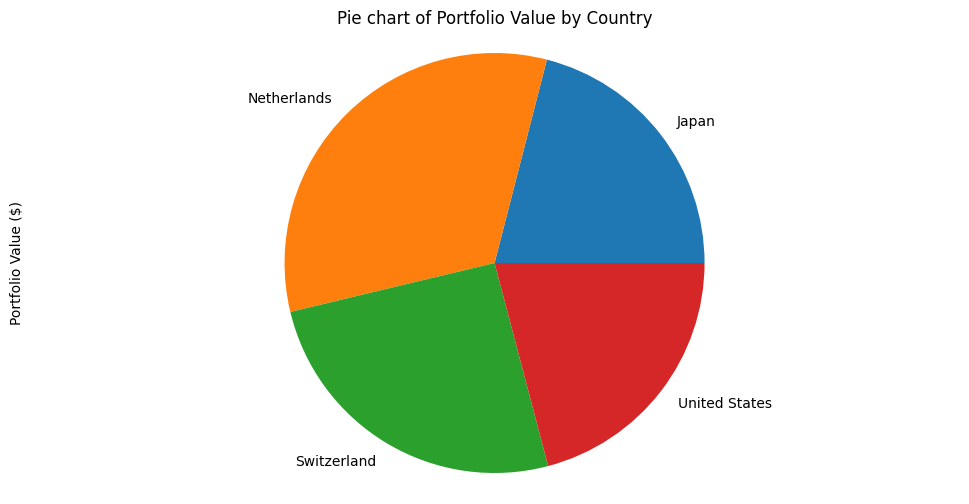

In [29]:
country_percentage.plot.pie(figsize = (12,6), ylabel="Portfolio Value ($)")
plt.title("Pie chart of Portfolio Value by Country")
plt.axis('equal')

plt.show()
